In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from tqdm.auto import tqdm
from collections import Counter

In [3]:
df = pd.read_csv('/workspaces/Machine-Learning-Zoomcamp-Homework/classification-03/data-week-3.csv')
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'str'].index)
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

# Process totalcharges
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')
df.totalcharges = df.totalcharges.fillna(0)

# Ensure correct binary encoding
df.churn = (df.churn == 'yes').astype(int)

In [4]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

In [5]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [14]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver = 'lbfgs' ,C=C, max_iter=5000)
    model.fit(X_train, y_train)
    
    return dv, model

In [15]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [16]:
dv, model = train(df_train, y_train, C=1)

    threshold  accuracy
51       0.51  0.806955
53       0.53  0.806246
52       0.52  0.805536
57       0.57  0.804826
56       0.56  0.803407


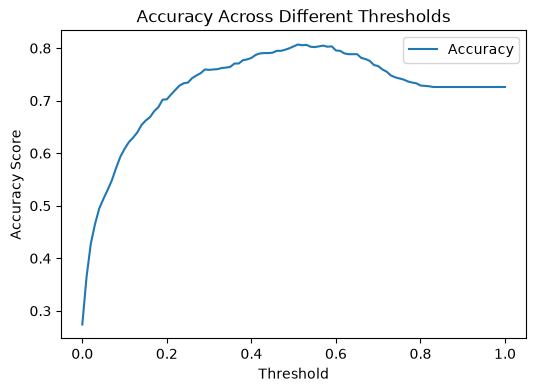

In [17]:
def accuracy_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)
    
    for t in thresholds:
        # Calculate accuracy score at threshold t
        score = accuracy_score(y_val, y_pred >= t)
        scores.append((t, score))
        
    df_acc = pd.DataFrame(scores, columns=['threshold', 'accuracy'])
    return df_acc

# 1. Ensure predictions match the validation set shape (1409 rows)
y_pred_val = predict(df_val, dv, model)

# 2. Call the function
df_accuracy = accuracy_dataframe(y_val, y_pred_val)

# 3. View the best threshold or plot the results
print(df_accuracy.sort_values(by='accuracy', ascending=False).head())

plt.figure(figsize=(6, 4))
plt.plot(df_accuracy.threshold, df_accuracy.accuracy, label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Accuracy Score')
plt.title('Accuracy Across Different Thresholds')
plt.legend()
plt.show()

In [25]:
def confusion_matrix(y_val , y_pred , t= 0.5):
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
        
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)
       
    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()
    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
            
    confusion_matrix = np.array([
                                 [tn, fp],
                                 [fn, tp]
                                ])
    return confusion_matrix

In [26]:
confusion_matrix(y_val , y_pred , t=0.5)

array([[920, 103],
       [174, 212]])

In [33]:
def confusion_matrix_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)
    
    for t in thresholds:
        conf_m = confusion_matrix(y_val , y_pred ,t)
        
        scores.append((t, conf_m[1][1], conf_m[0][1], conf_m[1][0], conf_m[0][0]))
        
    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_confusion = pd.DataFrame(scores, columns=columns)
    return df_confusion

In [34]:
# 2. Call the function
df_cm = confusion_matrix_dataframe(y_val, y_pred_val)

# 3. View the confusion matrix breakdown at different thresholds (e.g., every 10 steps)
print(df_cm[::10])

     threshold   tp    fp   fn    tn
0          0.0  386  1023    0     0
10         0.1  366   532   20   491
20         0.2  339   372   47   651
30         0.3  293   247   93   776
40         0.4  253   175  133   848
50         0.5  212   103  174   920
60         0.6  151    53  235   970
70         0.7   69    13  317  1010
80         0.8    4     0  382  1023
90         0.9    0     0  386  1023
100        1.0    0     0  386  1023


In [35]:
def precision_recall_dataframe(y_val, y_pred):
    scores = []
    thresholds = np.linspace(0, 1, 101)
    
    for t in thresholds:
        conf_m = confusion_matrix(y_val , y_pred ,t)
        
        scores.append((t, conf_m[1][1], conf_m[0][1], conf_m[1][0], conf_m[0][0]))
        
    columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
    df_scores = pd.DataFrame(scores, columns=columns)
    
    # Calculate Precision and Recall
    df_scores['precision'] = df_scores.tp / (df_scores.tp + df_scores.fp)
    df_scores['recall'] = df_scores.tp / (df_scores.tp + df_scores.fn)
    
    return df_scores


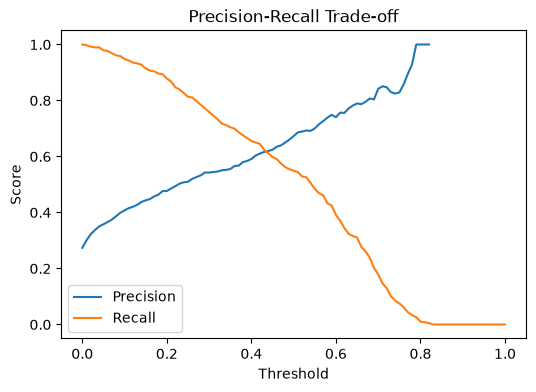

In [36]:
# Call the function using your validation targets and predictions
df_pr = precision_recall_dataframe(y_val, y_pred)

# Plot Precision and Recall against Thresholds
plt.figure(figsize=(6, 4))
plt.plot(df_pr.threshold, df_pr['precision'], label='Precision')
plt.plot(df_pr.threshold, df_pr['recall'], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.title('Precision-Recall Trade-off')
plt.show()

In [37]:
# 1. Train a dummy model that always returns zeros (False)
def train_dummy(df_train, y_train):
    # We can just return a constant or a dummy predictor object
    return None

# 2. Predict using the dummy model (returning an array of zeros matching the validation shape)
def predict_dummy(df, model=None):
    # Always returns 0.0 probability for each row (meaning 'False' for churn)
    y_pred = np.zeros(len(df))
    return y_pred


In [38]:
y_pred_dummy = predict_dummy(df_val)

In [39]:
# Check accuracy
df_dummy_acc = accuracy_dataframe(y_val, y_pred_dummy)
print(df_dummy_acc.head())

# Check confusion matrix breakdown
df_dummy_cm = confusion_matrix_dataframe(y_val, y_pred_dummy)
print(df_dummy_cm[::10])

   threshold  accuracy
0       0.00  0.273953
1       0.01  0.726047
2       0.02  0.726047
3       0.03  0.726047
4       0.04  0.726047
     threshold   tp    fp   fn    tn
0          0.0  386  1023    0     0
10         0.1    0     0  386  1023
20         0.2    0     0  386  1023
30         0.3    0     0  386  1023
40         0.4    0     0  386  1023
50         0.5    0     0  386  1023
60         0.6    0     0  386  1023
70         0.7    0     0  386  1023
80         0.8    0     0  386  1023
90         0.9    0     0  386  1023
100        1.0    0     0  386  1023


In [40]:
# 1. Print Accuracy at t = 1.0
acc_t1 = df_dummy_acc[df_dummy_acc['threshold'] == 1.0]
print("Accuracy at t = 1.0:")
print(acc_t1)

print("-" * 40)

# 2. Print Confusion Matrix components at t = 1.0
cm_t1 = df_dummy_cm[df_dummy_cm['threshold'] == 1.0]
print("Confusion Matrix at t = 1.0:")
print(cm_t1)

Accuracy at t = 1.0:
     threshold  accuracy
100        1.0  0.726047
----------------------------------------
Confusion Matrix at t = 1.0:
     threshold  tp  fp   fn    tn
100        1.0   0   0  386  1023


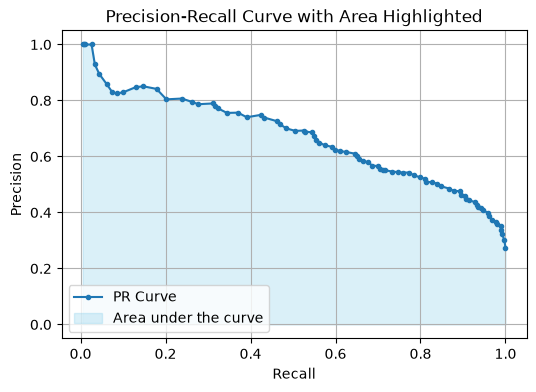

In [44]:
# 1. Generate the DataFrame containing thresholds, confusion components, precision, and recall
df_tpr = precision_recall_dataframe(y_val, y_pred_val)

# 2. Plot the Precision-Recall curve matching the diagram's visualization concept
# 1. Plot the Precision-Recall curve and fill the area underneath
plt.figure(figsize=(6, 4))
plt.plot(df_tpr.recall, df_tpr.precision, label='PR Curve', marker='.')

# Highlight/fill the area under the curve
plt.fill_between(df_tpr.recall, df_tpr.precision, alpha=0.3, color='skyblue', label='Area under the curve')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve with Area Highlighted')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

In [45]:
def f1_score_dataframe(df_scores):
    # Create a copy or add to the existing dataframe
    df_f1 = df_scores.copy()
    
    # Avoid division by zero warnings if precision + recall is 0
    denominator = df_f1['precision'] + df_f1['recall']
    df_f1['f1'] = np.where(
        denominator == 0, 
        0, 
        (2 * df_f1['precision'] * df_f1['recall']) / denominator
    )
    return df_f1

In [46]:
# 1. Generate precision and recall dataframe
df_pr = precision_recall_dataframe(y_val, y_pred_val)

# 2. Add F1 scores
df_pr_f1 = f1_score_dataframe(df_pr)

# 3. View the thresholds with the highest F1 score
print(df_pr_f1.sort_values(by='f1', ascending=False).head())

    threshold   tp   fp  fn   tn  precision    recall        f1
29       0.29  298  251  88  772   0.542805  0.772021  0.637433
28       0.28  303  266  83  757   0.532513  0.784974  0.634555
27       0.27  308  277  78  746   0.526496  0.797927  0.634398
26       0.26  313  289  73  734   0.519934  0.810881  0.633603
30       0.30  293  247  93  776   0.542593  0.759067  0.632829


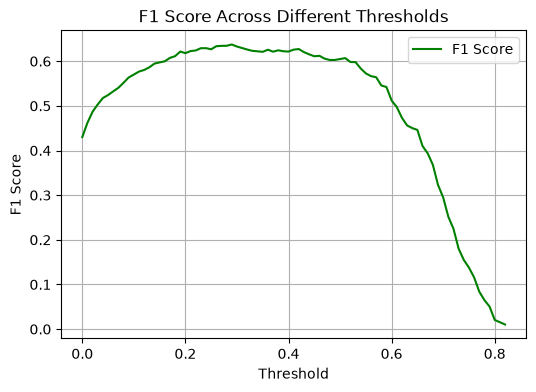

In [47]:
plt.figure(figsize=(6, 4))
plt.plot(df_pr_f1.threshold, df_pr_f1.f1, label='F1 Score', color='green')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score Across Different Thresholds')
plt.grid(True)
plt.legend()
plt.show()